In [3]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# Configurazione base
BASE_PATH = "../mcd_rppg_data" # <--- INSERISCI QUI IL TUO PERCORSO
ECG_FILENAME = "ecg/1020_after.json" # <--- INSERISCI QUI IL NOME DI UN FILE ECG
file_path = os.path.join(BASE_PATH, ECG_FILENAME)

print(f"Percorso target: {file_path}")

Percorso target: ../mcd_rppg_data/ecg/1020_after.json


In [4]:
# Caricamento del file JSON
try:
    with open(file_path, 'r') as f:
        data = json.load(f)

    print(f"Tipo di dato principale: {type(data)}")

    if isinstance(data, dict):
        print("\n--- CHIAVI TROVATE NEL DIZIONARIO ---")
        for key, value in data.items():
            print(f"Key: '{key}' | Tipo: {type(value)}")
            if isinstance(value, list):
                print(f"   -> Lunghezza lista: {len(value)}")
                print(f"   -> Esempio primi 5 elementi: {value[:5]}")
            elif isinstance(value, (int, float, str)):
                print(f"   -> Valore: {value}")
    
    elif isinstance(data, list):
        print(f"\n--- IL FILE È UNA LISTA DIRETTA ---")
        print(f"Lunghezza totale: {len(data)}")
        print(f"Primi 5 elementi: {data[:5]}")

except Exception as e:
    print(f"Errore nella lettura del file: {e}")

Tipo di dato principale: <class 'dict'>

--- CHIAVI TROVATE NEL DIZIONARIO ---
Key: '@odata.context' | Tipo: <class 'str'>
   -> Valore: http://192.168.6.15/api/v4/$metadata#Medmon.EcgDataApi
Key: 'frequency' | Tipo: <class 'int'>
   -> Valore: 500
Key: 'dataX' | Tipo: <class 'list'>
   -> Lunghezza lista: 15000
   -> Esempio primi 5 elementi: [0, 0.002, 0.004, 0.006, 0.008]
Key: 'data' | Tipo: <class 'list'>
   -> Lunghezza lista: 12
   -> Esempio primi 5 elementi: [{'title': 'I', 'values': [0.010238697599939272, 0.00902639363836164, 0.00883441650601308, 0.007967017596893734, 0.008559697693177649, 0.009979106889496584, 0.013711140737827381, 0.015878968617134753, 0.015885081470567414, 0.015299479884477286, 0.013861780335607492, 0.009780339956973494, 0.006991814580764085, 0.0031666185293084148, 0.001375211240379338, -4.7791690964928994e-05, 0.001433792362853552, 0.0026890410072992733, 0.0034661302629566573, 0.00649838045197165, 0.005641987648397747, 0.005730431389761887, 0.0069430159857

In [21]:
print(data.keys())
ecg_derivation = len(data['data'])

for elem in data['data']:
    print(elem.keys())
    derivazione = elem['title']
    print(f"Derivazione: {derivazione}")

dict_keys(['@odata.context', 'frequency', 'dataX', 'data', 'segmentsData'])
dict_keys(['title', 'values'])
Derivazione: I
dict_keys(['title', 'values'])
Derivazione: II
dict_keys(['title', 'values'])
Derivazione: V1
dict_keys(['title', 'values'])
Derivazione: V2
dict_keys(['title', 'values'])
Derivazione: V3
dict_keys(['title', 'values'])
Derivazione: V4
dict_keys(['title', 'values'])
Derivazione: V5
dict_keys(['title', 'values'])
Derivazione: V6
dict_keys(['title', 'values'])
Derivazione: III
dict_keys(['title', 'values'])
Derivazione: aVR
dict_keys(['title', 'values'])
Derivazione: aVL
dict_keys(['title', 'values'])
Derivazione: aVF


In [22]:
segments_data = data['segmentsData']
print(f"Chiavi in segmentsData: {segments_data.keys()}")

Chiavi in segmentsData: dict_keys(['pqAverageValue', 'qtAverageValue', 'stAverageValue', 'pqIntervals', 'qtIntervals', 'stSegments'])


Frequenza di campionamento rilevata: 250 Hz
Visualizzazione Derivazione: II
Lunghezza totale segnale: 15000 campioni (60.00 secondi)


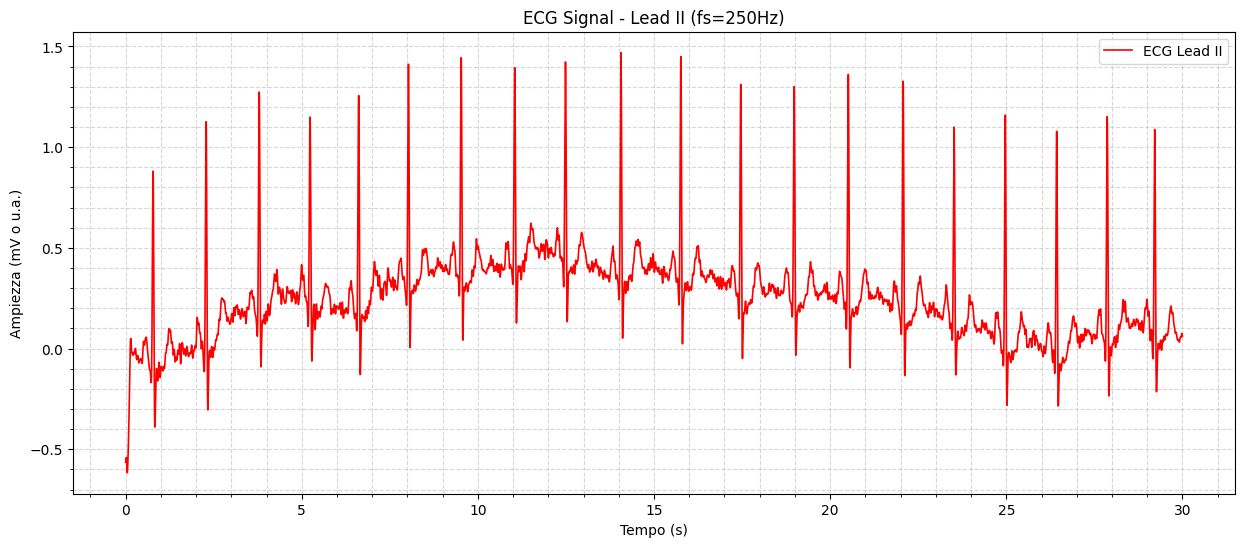

--- Statistiche Segmento (0-30s) ---
Min: -0.6161
Max: 1.4686
Media: 0.2528
Std Dev: 0.2206


In [ ]:
# --- PARAMETRI CONFIGURABILI ---
SECONDI_DA_VEDERE = 30   # Quanti secondi di segnale vuoi vedere
START_SECOND = 0        # Da che secondo iniziare a visualizzare
LEAD_INDEX = 1          # Indice della derivazione (0 = Prima derivazione disponibile, es. 'I')
# -------------------------------

try:
    # 1. Recupero Frequenza di Campionamento
    # Se non c'è, mettiamo 500 come default visto che l'abbiamo letto nell'analisi
    fs = data.get('frequency', 500) 
    print(f"Frequenza di campionamento rilevata: {fs} Hz")

    # 2. Recupero del Segnale
    # La struttura è: dict -> 'data' (lista) -> [0] (dict) -> 'values' (lista)
    leads_data = data.get('data', [])
    
    if not leads_data:
        raise ValueError("La lista 'data' è vuota. Nessun segnale trovato.")
    
    # Se l'indice richiesto è fuori range, prendiamo il primo
    if LEAD_INDEX >= len(leads_data):
        print(f"Attenzione: Indice {LEAD_INDEX} non valido. Uso l'indice 0.")
        LEAD_INDEX = 0

    selected_lead = leads_data[LEAD_INDEX]
    lead_name = selected_lead.get('title', 'Unknown')
    ecg_signal = np.array(selected_lead.get('values', []))
    
    print(f"Visualizzazione Derivazione: {lead_name}")
    print(f"Lunghezza totale segnale: {len(ecg_signal)} campioni ({len(ecg_signal)/fs:.2f} secondi)")

    # 3. Calcolo Indici per il taglio temporale
    start_idx = int(START_SECOND * fs)
    end_idx = int((START_SECOND + SECONDI_DA_VEDERE) * fs)

    # Controllo che non stiamo chiedendo dati oltre la fine del file
    if start_idx >= len(ecg_signal):
        print("ERRORE: Il punto di partenza (START_SECOND) è oltre la durata del segnale.")
    else:
        # Taglio sicuro (se end_idx supera la fine, si ferma alla fine)
        segment = ecg_signal[start_idx : min(end_idx, len(ecg_signal))]
        
        # Creazione asse temporale relativo alla finestra
        # (Parte da START_SECOND e avanza di 1/fs per ogni campione)
        time_axis = np.linspace(START_SECOND, START_SECOND + len(segment)/fs, len(segment))

        # 4. Plotting
        plt.figure(figsize=(15, 6))
        plt.plot(time_axis, segment, color='red', linewidth=1.2, label=f'ECG Lead {lead_name}')
        
        plt.title(f"ECG Signal - Lead {lead_name} (fs={fs}Hz)")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Ampiezza (mV o u.a.)")
        plt.legend(loc='upper right')
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.minorticks_on()
        plt.show()

        # Statistiche di base del segmento visualizzato
        print(f"--- Statistiche Segmento ({START_SECOND}-{START_SECOND+SECONDI_DA_VEDERE}s) ---")
        print(f"Min: {np.min(segment):.4f}")
        print(f"Max: {np.max(segment):.4f}")
        print(f"Media: {np.mean(segment):.4f}")
        print(f"Std Dev: {np.std(segment):.4f}")

except Exception as e:
    print(f"Si è verificato un errore durante l'elaborazione: {e}")

In [27]:
# Cella 4: Calcolo della Durata della Misurazione

try:
    # 1. Recuperiamo la frequenza (già sappiamo che è 500, ma lo prendiamo dinamicamente)
    fs = data.get('frequency', 500)
    
    # 2. Recuperiamo il numero di campioni
    # Controlliamo se ci sono dati nelle derivazioni
    leads = data.get('data', [])
    
    if leads:
        # Prendiamo la lunghezza della prima derivazione (es. 'I')
        # Si assume che tutte le derivazioni abbiano la stessa lunghezza temporale
        first_lead_values = leads[0].get('values', [])
        total_samples = len(first_lead_values)
        
        # 3. Calcolo Tempo
        duration_seconds = total_samples / fs
        duration_minutes = duration_seconds / 60
        
        # 4. Stampa Risultati
        print(f"{'='*40}")
        print(f"ANALISI DURATA REGISTRAZIONE")
        print(f"{'='*40}")
        print(f"Frequenza (fs):      {fs} Hz")
        print(f"Totale Campioni:     {total_samples}")
        print(f"Durata (Secondi):    {duration_seconds:.2f} s")
        print(f"Durata (Minuti):     {duration_minutes:.2f} min")
        
        # Formato leggibile (Minuti : Secondi)
        mins = int(duration_minutes)
        secs = int(duration_seconds % 60)
        print(f"Durata Leggibile:    {mins} min {secs} s")
        print(f"{'='*40}")
        
    else:
        print("Errore: La lista 'data' è vuota o non trovata.")

except Exception as e:
    print(f"Errore durante il calcolo: {e}")

ANALISI DURATA REGISTRAZIONE
Frequenza (fs):      500 Hz
Totale Campioni:     14900
Durata (Secondi):    29.80 s
Durata (Minuti):     0.50 min
Durata Leggibile:    0 min 29 s


In [29]:
# Cella 5: Verifica Consistenza Dataset (Batch Processing)

import os
import json

# --- CONFIGURAZIONE ---
# Inserisci qui il percorso della cartella contenente i file JSON dell'ECG
ECG_FOLDER_PATH = "../mcd_rppg_data/ecg" 
# ----------------------

def analyze_file_group(group_name, file_list, base_path):
    print(f"\n{'='*20} ANALISI GRUPPO: {group_name.upper()} ({len(file_list)} files) {'='*20}")
    
    if not file_list:
        print("⚠️ Nessun file trovato per questo gruppo.")
        return

    # Parametri di riferimento (settati dal primo file valido)
    ref_length = None
    ref_fs = None
    ref_keys = None
    
    # Liste per tracciare gli errori
    len_mismatches = []
    fs_mismatches = []
    structure_errors = []
    io_errors = []

    # Ordiniamo per avere un riferimento deterministico
    for filename in sorted(file_list):
        filepath = os.path.join(base_path, filename)
        
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
            
            # 1. Controllo Struttura Chiavi
            current_keys = set(data.keys())
            if ref_keys is None:
                ref_keys = current_keys
                # Controllo minimo vitale
                if 'frequency' not in data or 'data' not in data:
                    structure_errors.append(f"{filename} (Mancano chiavi 'frequency' o 'data')")
                    continue
            else:
                if current_keys != ref_keys:
                    structure_errors.append(f"{filename} (Chiavi diverse dal riferimento)")

            # 2. Estrazione Parametri
            curr_fs = data.get('frequency')
            leads = data.get('data', [])
            
            if not isinstance(leads, list) or len(leads) == 0:
                structure_errors.append(f"{filename} (Lista 'data' vuota o non valida)")
                continue
                
            # Prendiamo la lunghezza della prima derivazione
            curr_len = len(leads[0].get('values', []))
            
            # 3. Confronto con il Riferimento
            if ref_length is None:
                # Impostiamo questo file come standard
                ref_length = curr_len
                ref_fs = curr_fs
                print(f"✅ File di Riferimento impostato: {filename}")
                print(f"   -> Campioni attesi: {ref_length}")
                print(f"   -> Frequenza attesa: {ref_fs} Hz")
            else:
                # Verifiche
                if curr_len != ref_length:
                    len_mismatches.append(f"{filename} (Ha {curr_len} campioni invece di {ref_length})")
                
                if curr_fs != ref_fs:
                    fs_mismatches.append(f"{filename} (Ha {curr_fs} Hz invece di {ref_fs} Hz)")
                    
        except Exception as e:
            io_errors.append(f"{filename}: {str(e)}")

    # --- REPORT FINALE GRUPPO ---
    if not (len_mismatches or fs_mismatches or structure_errors or io_errors):
        print(f"\n[OK] 🎉 Tutti i file {group_name} sono coerenti!")
    else:
        print(f"\n[ATTENZIONE] ❌ Trovate incongruenze nel gruppo {group_name}:")
        
        if len_mismatches:
            print(f"\n1. ERRORE LUNGHEZZA ({len(len_mismatches)} files):")
            for err in len_mismatches[:10]: print(f"   - {err}")
            if len(len_mismatches) > 10: print("   ... (altri nascosti)")
            
        if fs_mismatches:
            print(f"\n2. ERRORE FREQUENZA ({len(fs_mismatches)} files):")
            for err in fs_mismatches: print(f"   - {err}")
            
        if structure_errors:
            print(f"\n3. ERRORE STRUTTURA JSON ({len(structure_errors)} files):")
            for err in structure_errors: print(f"   - {err}")

        if io_errors:
            print(f"\n4. ERRORE LETTURA FILE ({len(io_errors)} files):")
            for err in io_errors: print(f"   - {err}")

# --- ESECUZIONE ---
try:
    all_files = [f for f in os.listdir(ECG_FOLDER_PATH) if f.endswith('.json')]
    
    # Filtro in base al suffisso richiesto
    before_files = [f for f in all_files if '_before.json' in f]
    after_files = [f for f in all_files if '_after.json' in f]
    
    # Analisi separata
    analyze_file_group("BEFORE", before_files, ECG_FOLDER_PATH)
    analyze_file_group("AFTER", after_files, ECG_FOLDER_PATH)

except FileNotFoundError:
    print(f"Errore: La cartella specificata non esiste: {ECG_FOLDER_PATH}")


==================== ANALISI GRUPPO: BEFORE (600 files) ====================
✅ File di Riferimento impostato: 1020_before.json
   -> Campioni attesi: 14900
   -> Frequenza attesa: 500 Hz

[ATTENZIONE] ❌ Trovate incongruenze nel gruppo BEFORE:

4. ERRORE LETTURA FILE (3 files):
   - 5214_before.json: Extra data: line 1 column 3130462 (char 3130461)
   - 5904_before.json: Extra data: line 1 column 3100106 (char 3100105)
   - 8001_before.json: Extra data: line 1 column 3106692 (char 3106691)

==================== ANALISI GRUPPO: AFTER (600 files) ====================
✅ File di Riferimento impostato: 1020_after.json
   -> Campioni attesi: 14900
   -> Frequenza attesa: 500 Hz

[OK] 🎉 Tutti i file AFTER sono coerenti!


In [30]:
import json
import os

# Lista dei file problematici segnalati dall'analisi precedente
problematic_files = [
    "5214_before.json",
    "5904_before.json",
    "8001_before.json"
]

# Assumiamo che ECG_FOLDER_PATH sia già definito dalle celle precedenti. 
# Se no, ridefiniscilo qui:
# ECG_FOLDER_PATH = "/path/to/your/ecg_folder"

print(f"{'='*20} DEBUG FILE CORROTTI {'='*20}")

for filename in problematic_files:
    filepath = os.path.join(ECG_FOLDER_PATH, filename)
    print(f"\n📄 Analisi file: {filename}")
    
    try:
        with open(filepath, 'r') as f:
            raw_content = f.read()
            
        print(f"   Dimensione totale (caratteri): {len(raw_content)}")
        
        # Tentiamo il parsing per trovare il punto esatto di rottura
        decoder = json.JSONDecoder()
        try:
            obj, idx = decoder.raw_decode(raw_content)
            print(f"   ✅ Primo oggetto JSON decodificato correttamente!")
            print(f"   -> Termina al carattere: {idx}")
            print(f"   -> Dati extra rimanenti: {len(raw_content) - idx} caratteri")
            
            # Mostriamo cosa c'è subito dopo la fine del primo JSON
            snippet = raw_content[idx : idx+100].replace('\n', '\\n')
            print(f"   -> Snippet dei dati extra (primi 100 char): '{snippet}...'")
            
            # Controllo se il primo oggetto è valido (ha i dati che ci servono?)
            if 'data' in obj and 'frequency' in obj:
                len_data = len(obj['data'][0]['values']) if obj['data'] else 0
                print(f"   -> Il PRIMO oggetto sembra valido: {len_data} campioni, {obj.get('frequency')} Hz")
                print("   💡 SUGGERIMENTO: Possiamo salvare solo la prima parte e scartare il resto.")
            else:
                print("   ⚠️ Il primo oggetto NON sembra contenere i dati ECG standard.")
                
        except json.JSONDecodeError as e:
            print(f"   ❌ Errore di decodifica immediato: {e}")

    except FileNotFoundError:
        print(f"   ❌ File non trovato: {filepath}")
    except Exception as e:
        print(f"   ❌ Errore generico: {e}")

==================== DEBUG FILE CORROTTI ====================

📄 Analisi file: 5214_before.json
   Dimensione totale (caratteri): 6581941
   ✅ Primo oggetto JSON decodificato correttamente!
   -> Termina al carattere: 3130461
   -> Dati extra rimanenti: 3451480 caratteri
   -> Snippet dei dati extra (primi 100 char): '{"@odata.context":"http://192.168.6.15/api/v4/$metadata#Medmon.EcgDataApi","frequency":500,"dataX":[...'
   -> Il PRIMO oggetto sembra valido: 14900 campioni, 500 Hz
   💡 SUGGERIMENTO: Possiamo salvare solo la prima parte e scartare il resto.

📄 Analisi file: 5904_before.json
   Dimensione totale (caratteri): 6214096
   ✅ Primo oggetto JSON decodificato correttamente!
   -> Termina al carattere: 3100105
   -> Dati extra rimanenti: 3113991 caratteri
   -> Snippet dei dati extra (primi 100 char): '{"@odata.context":"http://192.168.6.15/api/v4/$metadata#Medmon.EcgDataApi","frequency":500,"dataX":[...'
   -> Il PRIMO oggetto sembra valido: 14900 campioni, 500 Hz
   💡 SUGGERIM

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONFIGURAZIONE ---
PPG_PATH = "../mcd_rppg_data/ppg/1020_after.PW"  # Inserisci il percorso del file .PW
# ----------------------

try:
    # 1. Caricamento del file
    # delim_whitespace=True gestisce spazi multipli come separatori
    # header=None perché non c'è intestazione
    df_ppg = pd.read_csv(PPG_PATH, sep=r'\s+', header=None, names=['ppg', 'date', 'time'])

    # 2. Creazione colonna Timestamp unico
    # Uniamo data e ora e convertiamo in oggetto datetime
    df_ppg['timestamp'] = pd.to_datetime(df_ppg['date'] + ' ' + df_ppg['time'])
    
    # 3. Calcolo Frequenza di Campionamento Reale
    # Calcoliamo la differenza in secondi tra ogni riga
    time_diffs = df_ppg['timestamp'].diff().dt.total_seconds().dropna()
    
    # Calcoliamo la media delle differenze
    avg_diff = time_diffs.mean()
    
    # Frequenza = 1 / Periodo
    real_fs = 1 / avg_diff if avg_diff > 0 else 0
    
    # Calcolo della stabilità (Jitter)
    # Se la deviazione standard è alta, il campionamento non è costante
    jitter = time_diffs.std()
    
    # 4. Report
    print(f"{'='*40}")
    print(f"ANALISI FILE: {os.path.basename(PPG_PATH)}")
    print(f"{'='*40}")
    print(f"Numero campioni:      {len(df_ppg)}")
    print(f"Durata totale:        {len(df_ppg) * avg_diff / 60:.2f} minuti")
    print(f"Delta t medio:        {avg_diff:.6f} s")
    print(f"Frequenza Reale (fs): {real_fs:.2f} Hz")
    print(f"Stabilità (Jitter):   {jitter:.6f} s")
    
    if abs(real_fs - 100) > 5:
        print("\n⚠️ ATTENZIONE: La frequenza rilevata si discosta significativamente dai 100Hz!")
    else:
        print("\n✅ CONFERMA: La frequenza è coerente con i 100Hz dichiarati.")

except Exception as e:
    print(f"Errore nell'analisi: {e}")

ANALISI FILE: 1020_after.PW
Numero campioni:      18051
Durata totale:        3.01 minuti
Delta t medio:        0.010000 s
Frequenza Reale (fs): 100.00 Hz
Stabilità (Jitter):   0.006366 s

✅ CONFERMA: La frequenza è coerente con i 100Hz dichiarati.


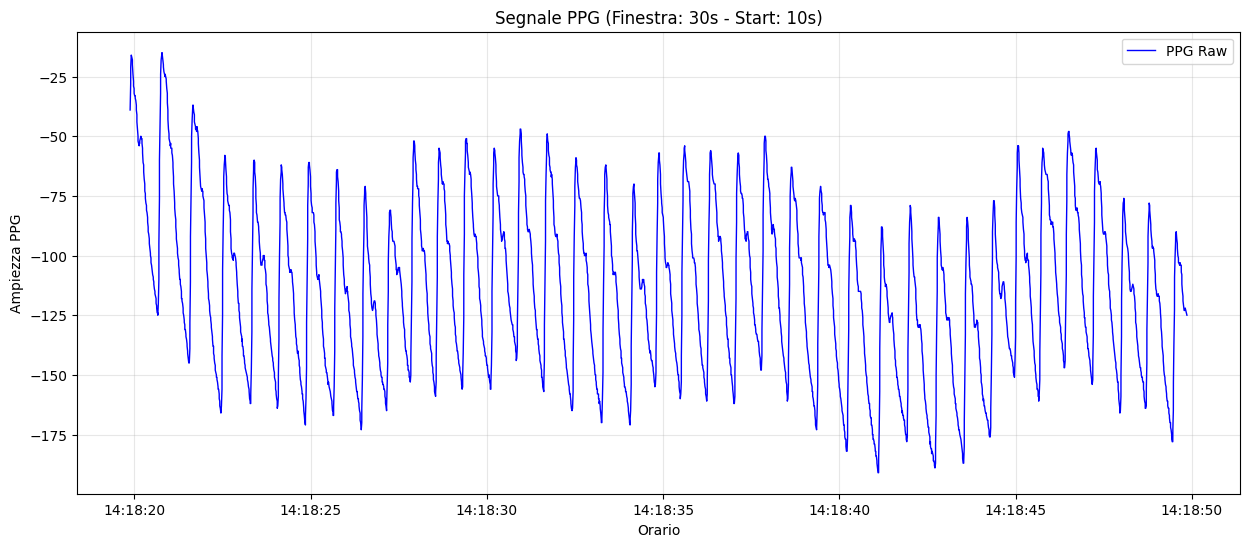

In [38]:
# --- PARAMETRI VISUALIZZAZIONE ---
START_SEC = 10   # Salta i primi 10 secondi (spesso rumorosi)
WINDOW_SEC = 30   # Visualizza una finestra di 5 secondi
# ---------------------------------

try:
    # Definiamo l'intervallo temporale
    start_time = df_ppg['timestamp'].iloc[0] + pd.Timedelta(seconds=START_SEC)
    end_time = start_time + pd.Timedelta(seconds=WINDOW_SEC)
    
    # Filtriamo i dati
    mask = (df_ppg['timestamp'] >= start_time) & (df_ppg['timestamp'] < end_time)
    segment = df_ppg.loc[mask]
    
    if segment.empty:
        print("Nessun dato trovato in questo intervallo temporale.")
    else:
        plt.figure(figsize=(15, 6))
        
        # Plot del segnale
        plt.plot(segment['timestamp'], -segment['ppg'], color='blue', linewidth=1, label='PPG Raw')
        
        plt.title(f"Segnale PPG (Finestra: {WINDOW_SEC}s - Start: {START_SEC}s)")
        plt.xlabel("Orario")
        plt.ylabel("Ampiezza PPG")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

except NameError:
    print("Errore: Esegui prima la Cella 1 per caricare 'df_ppg'.")
except Exception as e:
    print(f"Errore nel plotting: {e}")


==================== STATISTICA BEFORE (600 files) ====================
   ... processing 0/600
   ... processing 100/600
   ... processing 200/600
   ... processing 300/600
   ... processing 400/600
   ... processing 500/600

✅ Nessun errore di lettura (Fix 8706 riuscito!)

📊 DISTRIBUZIONE LUNGHEZZE:
   Min:    17947
   Max:    19607
   Media:  18081.61
   Mediana:18057.00
   MODA (Più comune): 18050 (presente in 27 file)


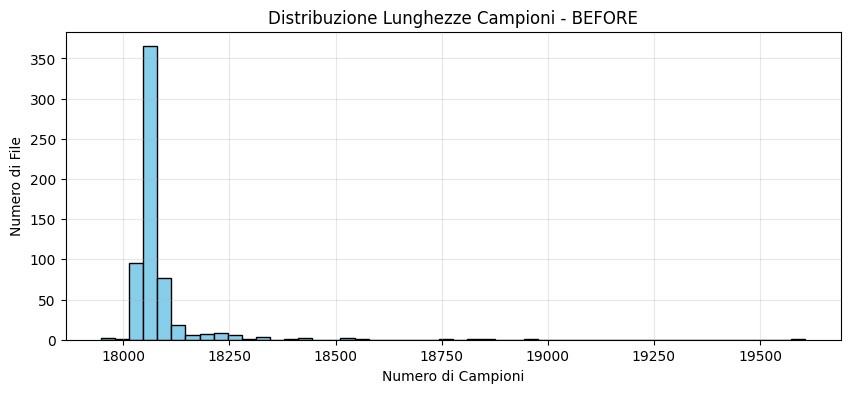

   Frequenza Media Stimata: 100.00 Hz

==================== STATISTICA AFTER (600 files) ====================
   ... processing 0/600
   ... processing 100/600
   ... processing 200/600
   ... processing 300/600
   ... processing 400/600
   ... processing 500/600

✅ Nessun errore di lettura (Fix 8706 riuscito!)

📊 DISTRIBUZIONE LUNGHEZZE:
   Min:    17927
   Max:    19456
   Media:  18089.90
   Mediana:18058.00
   MODA (Più comune): 18051 (presente in 27 file)


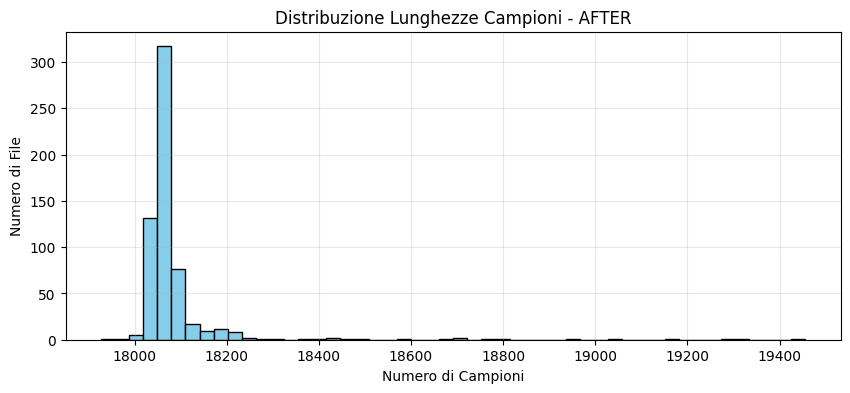

   Frequenza Media Stimata: 100.00 Hz


In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE ---
PPG_FOLDER_PATH = "../mcd_rppg_data/ppg" 
# ----------------------

def robust_ppg_reader(filepath):
    """
    Legge il file forzando i tipi a stringa per evitare TypeError.
    Restituisce lunghezza e frequenza stimata.
    """
    try:
        # dtype=str risolve il problema "can only concatenate str (not float)"
        df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['val', 'date', 'time'], dtype=str)
        
        # Conversione valori segnale a numerico (gestione errori)
        df['val'] = pd.to_numeric(df['val'], errors='coerce')
        df = df.dropna(subset=['val']) # Rimuove righe dove il segnale non è numero
        
        n_samples = len(df)
        if n_samples < 2: return n_samples, 0.0

        # Calcolo Frequenza
        start_str = str(df.iloc[0]['date']) + ' ' + str(df.iloc[0]['time'])
        end_str = str(df.iloc[-1]['date']) + ' ' + str(df.iloc[-1]['time'])
        
        # Coerce gestisce date malformate trasformandole in NaT
        start_time = pd.to_datetime(start_str, errors='coerce')
        end_time = pd.to_datetime(end_str, errors='coerce')
        
        if pd.isna(start_time) or pd.isna(end_time):
            return n_samples, 0.0 # Impossibile calcolare frequenza
            
        duration = (end_time - start_time).total_seconds()
        fs_est = (n_samples - 1) / duration if duration > 0 else 0.0
        
        return n_samples, fs_est

    except Exception as e:
        return None, str(e) # Ritorna l'errore per il report

def analyze_distribution(group_name, file_list, base_path):
    print(f"\n{'='*20} STATISTICA {group_name} ({len(file_list)} files) {'='*20}")
    
    lengths = []
    frequencies = []
    errors = []
    
    for i, f in enumerate(sorted(file_list)):
        if i % 100 == 0: print(f"   ... processing {i}/{len(file_list)}")
        
        fpath = os.path.join(base_path, f)
        l, fs = robust_ppg_reader(fpath)
        
        if l is None: # Errore
            errors.append(f"{f}: {fs}")
        else:
            lengths.append(l)
            if fs > 0: frequencies.append(fs)

    # --- ANALISI RISULTATI ---
    if errors:
        print(f"\n❌ ERRORI DI LETTURA ({len(errors)} files):")
        for e in errors: print(f"   - {e}")
    else:
        print("\n✅ Nessun errore di lettura (Fix 8706 riuscito!)")

    if lengths:
        lengths = np.array(lengths)
        print(f"\n📊 DISTRIBUZIONE LUNGHEZZE:")
        print(f"   Min:    {np.min(lengths)}")
        print(f"   Max:    {np.max(lengths)}")
        print(f"   Media:  {np.mean(lengths):.2f}")
        print(f"   Mediana:{np.median(lengths):.2f}")
        
        # Moda (Valore più frequente)
        vals, counts = np.unique(lengths, return_counts=True)
        mode_idx = np.argmax(counts)
        print(f"   MODA (Più comune): {vals[mode_idx]} (presente in {counts[mode_idx]} file)")

        # Plot Istogramma
        plt.figure(figsize=(10, 4))
        plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
        plt.title(f"Distribuzione Lunghezze Campioni - {group_name}")
        plt.xlabel("Numero di Campioni")
        plt.ylabel("Numero di File")
        plt.grid(alpha=0.3)
        plt.show() # 
        
    if frequencies:
        print(f"   Frequenza Media Stimata: {np.mean(frequencies):.2f} Hz")

# --- ESECUZIONE ---
all_files = [f for f in os.listdir(PPG_FOLDER_PATH) if f.endswith('.PW')]
before_files = [f for f in all_files if '_before.PW' in f]
after_files = [f for f in all_files if '_after.PW' in f]

analyze_distribution("BEFORE", before_files, PPG_FOLDER_PATH)
analyze_distribution("AFTER", after_files, PPG_FOLDER_PATH)

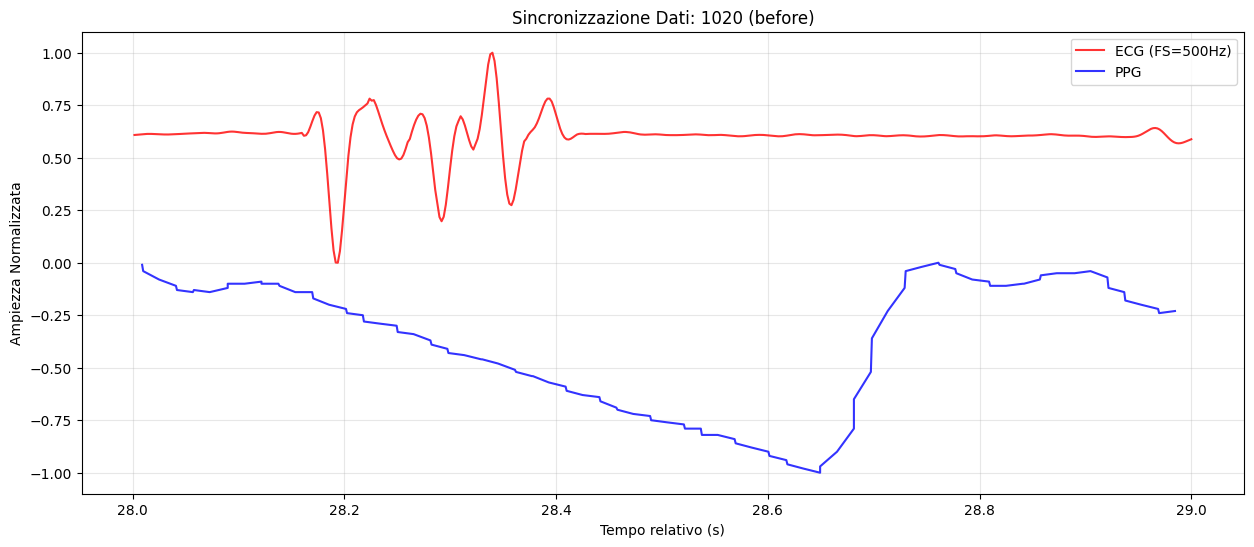

Punti ECG visualizzati: 500
Punti PPG visualizzati: 99


In [63]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE ---
ECG_FOLDER = "../mcd_rppg_data/ecg"
PPG_FOLDER = "../mcd_rppg_data/ppg"

# Modifica questi parametri per esplorare
SUBJECT_ID = "1020"    # Esempio: "1020", "5214"
SESSION = "before"      # "before" o "after"
START_SEC = 28          # A che secondo iniziare a guardare
WINDOW_SEC = 1         # Quanti secondi visualizzare
# ----------------------

def normalize_minmax(signal):
    """Normalizza tra 0 e 1 per sovrapporre i grafici."""
    s_min, s_max = np.min(signal), np.max(signal)
    return (signal - s_min) / (s_max - s_min + 1e-8)

try:
    # 1. CARICAMENTO ECG (.json)
    ecg_filename = f"{SUBJECT_ID}_{SESSION}.json"
    ecg_path = os.path.join(ECG_FOLDER, ecg_filename)
    
    with open(ecg_path, 'r') as f:
        ecg_data = json.load(f)
    
    ecg_fs = ecg_data.get('frequency', 500)
    # Prende la prima derivazione
    ecg_signal = np.array(ecg_data['data'][0]['values'])
    
    # Asse tempi ECG (0, 1/fs, 2/fs ...)
    ecg_time = np.linspace(0, len(ecg_signal) / ecg_fs, len(ecg_signal))

    # 2. CARICAMENTO PPG (.PW)
    ppg_filename = f"{SUBJECT_ID}_{SESSION}.PW"
    ppg_path = os.path.join(PPG_FOLDER, ppg_filename)
    
    # dtype=str serve per evitare l'errore di parsing misto
    df_ppg = pd.read_csv(ppg_path, sep=r'\s+', header=None, names=['val', 'date', 'time'], dtype=str)
    
    # Conversione valori
    df_ppg['val'] = pd.to_numeric(df_ppg['val'], errors='coerce')
    df_ppg = df_ppg.dropna(subset=['val'])
    ppg_signal = df_ppg['val'].values
    
    # Calcolo asse tempi PPG in secondi relativi
    # Convertiamo stringhe data/ora in oggetti datetime
    timestamps = pd.to_datetime(df_ppg['date'] + ' ' + df_ppg['time'], errors='coerce')
    # Sottraiamo il primo timestamp per far partire tutto da 0.0 secondi
    ppg_time = (timestamps - timestamps.iloc[0]).dt.total_seconds().values

    # 3. FILTRAGGIO FINESTRA (Slicing)
    # Maschere booleane per selezionare solo i dati nel range richiesto
    mask_ecg = (ecg_time >= START_SEC) & (ecg_time < START_SEC + WINDOW_SEC)
    mask_ppg = (ppg_time >= START_SEC) & (ppg_time < START_SEC + WINDOW_SEC)
    
    ecg_plot = ecg_signal[mask_ecg]
    ecg_t_plot = ecg_time[mask_ecg]
    
    ppg_plot = ppg_signal[mask_ppg]
    ppg_t_plot = ppg_time[mask_ppg]

    # 4. PLOTTING
    if len(ecg_plot) == 0 or len(ppg_plot) == 0:
        print(f"Nessun dato trovato nel range {START_SEC}-{START_SEC+WINDOW_SEC}s.")
    else:
        plt.figure(figsize=(15, 6))
        
        # Plot ECG (Rosso) - Normalizzato
        plt.plot(ecg_t_plot, normalize_minmax(ecg_plot), 
                 color='red', label=f'ECG (FS={ecg_fs}Hz)', alpha=0.8)
        
        # Plot PPG (Blu) - Normalizzato
        plt.plot(ppg_t_plot, -normalize_minmax(ppg_plot), 
                 color='blue', label='PPG', alpha=0.8)
        
        plt.title(f"Sincronizzazione Dati: {SUBJECT_ID} ({SESSION})")
        plt.xlabel("Tempo relativo (s)")
        plt.ylabel("Ampiezza Normalizzata")
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"Punti ECG visualizzati: {len(ecg_plot)}")
        print(f"Punti PPG visualizzati: {len(ppg_plot)}")

except FileNotFoundError as e:
    print(f"File mancante: {e}")
except Exception as e:
    print(f"Errore: {e}")